In [1]:
!pip install kagglehub pandas scikit-learn matplotlib

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [40]:
rng = 42
test_size = 0.25
dev_mode = True
dev_dpi = 100
prod_dpi = 1000
optimize = {
    "Logistic Regression": True,
    "Decision Tree": True
}
models = {}

# Rain in Australia

## Motivation and Question

## Target Variable and Class Labels

## Data Source, Observations, and Main Features

### Import Dataset

In [4]:
import kagglehub
from pathlib import Path

# Download latest version
handle = "jsphyg/weather-dataset-rattle-package"
path = "weatherAUS.csv"
if not Path(path).exists():
    print("Downloading from Kaggle")
    path = kagglehub.dataset_download(
        "jsphyg/weather-dataset-rattle-package",
        "weatherAUS.csv",
        output_dir="."
    )

print("Path to dataset files:", path)

Path to dataset files: weatherAUS.csv


/Users/ben/Docs/College/Waseda/Intermediate Data Science/ids_pbl2_rain-in-australia/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
import pandas as pd

df = pd.read_csv(path)

## Cleaning and Preprocessing

* Handling null values should happend before enrichment.
    * Except some enrichment should happend before getting rid of null values. For example, consecutive rain days
* Enrichment should happen before EDA
* EDA should happen before preprocessing
* Some amount of EDA should handle any imputed (estimated and added in) null values, if we're using any
    * E.g. Box plot with and without imputed values

* Handle categorical values ([ordinal][sklearn.preprocessing.OrdinalEncoder], [one-hot][sklearn.preprocessing.OneHotEncoder], [target][sklearn.preprocessing.TargetEncoder])
* [Standardize scalers][sklearn.preprocessing.StandardScaler]?
* Handle null values
    * Delete: simply drop any rows/columns with missing values, especially if they are few and missingness is random
    * Impute: replace with estimated values
        * with mean, median, or mode
        * using forward/backward fill - duplicating in the previous/next seen value...
    * Interpolate from nearby values...

[sklearn.preprocessing.OrdinalEncoder]: https://scikit-learn.org/1.9/modules/generated/sklearn.preprocessing.OrdinalEncoder.html#sklearn.preprocessing.OrdinalEncoder
[sklearn.preprocessing.OneHotEncoder]: https://scikit-learn.org/1.9/modules/generated/sklearn.preprocessing.OneHotEncoder.html#sklearn.preprocessing.OneHotEncoder
[sklearn.preprocessing.TargetEncoder]: https://scikit-learn.org/1.9/modules/generated/sklearn.preprocessing.TargetEncoder.html#sklearn.preprocessing.TargetEncoder
[sklearn.preprocessing.StandardScaler]: https://scikit-learn.org/1.9/modules/generated/sklearn.preprocessing.StandardScaler.html

According to the [Australian Government's Bureau of Meterology](https://www.bom.gov.au/climate/dwo/IDCJDW0000.shtml), "From time to time, observations will not be available, for a variety of reasons. Sometimes when the daily maximum and minimum temperatures, rainfall or evaporation are missing, the next value given has been accumulated over several days rather than the normal one day. It is very difficult for an automatic system to detect this reliably, so caution is advised."

In [6]:
print(f"Number of columns with a significant amount of missing data: {((df.isnull().sum() / df.shape[0]) > 0.05).sum()} / {df.shape[1]} = {((df.isnull().sum() / df.shape[0]) > 0.05).sum() / df.shape[1]}")
print(f"Number of rows with at least one missing feature: {(df.isnull().sum(axis=1) > 0).sum()} / {df.shape[0]} = {(df.isnull().sum(axis=1) > 0).sum() / df.shape[0]}")
print(f"Number of rows with more than one missing feature: {(df.isnull().sum(axis=1) > 2).sum()} / {df.shape[0]} = {(df.isnull().sum(axis=1) > 2).sum() / df.shape[0]}")

Number of columns with a significant amount of missing data: 9 / 23 = 0.391304347826087
Number of rows with at least one missing feature: 89040 / 145460 = 0.6121270452358036
Number of rows with more than one missing feature: 59785 / 145460 = 0.41100646225766535


### Enrich Dataset
- TempRange — MaxTemp minus MinTemp
- MonsoonSeason — location-aware wet/monsoon flag (Yes/No)
- WindSpeedDiff — WindSpeed3pm minus WindSpeed9am (signed)
- HumidityDiff — Humidity3pm minus Humidity9am (signed)
- TempDiff9am3pm — Temp3pm minus Temp9am (signed)
- PressureDiff — Pressure3pm minus Pressure9am (signed)
- DewPoint9am — dew point from 9am temp and humidity
- Season — Southern Hemisphere season from date
- DaysSinceRain — days since last rain per location
- ConsecutiveRainDays — consecutive rainy days before current day
- LaNina — monthly La Niña flag from NOAA NINO3.4 anomaly

In [7]:
from enrich_weather import enrich
df = enrich(df)

In [8]:
print("Number of columns with a significant amount of missing data", ((df.isnull().sum() / df.shape[0]) > 0.05).sum())
print(f"Number of rows with no missing features: {(df.isnull().sum(axis=1) == 0).sum()} / {df.shape[0]} = {(df.isnull().sum(axis=1) == 0).sum() / df.shape[0]}")

Number of columns with a significant amount of missing data 10
Number of rows with no missing features: 56046 / 145460 = 0.38530180118245566


## Exploratory Data Analysis
e.g. Description: columns, data-types, null values, counts, mean, standard deviation, box plot: min, 25%, 50%, 75% max; Distribution: target, target vs. key features, correlation matrix; target class balance

## Train-Test Split

In [9]:
# TODO: This is not an acceptable handling of null values. But it's good enough for getting started on the modelling
df = df.dropna()
print(f"Number of rows with no missing features: {(df.isnull().sum(axis=1) == 0).sum()} / {df.shape[0]} = {(df.isnull().sum(axis=1) == 0).sum() / df.shape[0]}")

Number of rows with no missing features: 56046 / 56046 = 1.0


### Preprocessing

[This wind modelling project](https://www.codespeedy.com/wind-direction-and-speed-prediction-using-machine-learning-in-python/) just uses degrees for the wind direction and get... passable results. I also can't think of a way to properly encode that mod activity of compass directions. One could just do it like this and another way (probably One-Hot) and see if you get a difference.

In [10]:
DIRECTIONS = ['N', 'NNE', 'NE', 'ENE',
              'E', 'ESE', 'SE', 'SSE', 
              'S', 'SSW', 'SW', 'WSW',
              'W', 'WNW', 'NW', 'NNW']
DEGREES = np.arange(0, 360, 360/len(DIRECTIONS))
DIRECTIONS_DEGREES = dict(zip(DIRECTIONS, DEGREES))
def direc_to_deg(direc: pd.DataFrame) -> float:
    return direc.map(str.upper).map(DIRECTIONS_DEGREES.get)

# Extra 1 and 0 entries for redundancy on multiple runnings
YES_NO_BINARY = { 'Yes': 1, 'No': 0,
                  1: 1,     0: 0 }
def yes_no_binary(b: pd.DataFrame) -> float:
    return b.map(YES_NO_BINARY.get)

In [11]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer, StandardScaler

preprocessing = make_column_transformer(
    (FunctionTransformer(direc_to_deg, feature_names_out="one-to-one"), ["WindGustDir", "WindDir9am", "WindDir3pm"]),
    (OneHotEncoder(), ["Location", "Season"]),
    (FunctionTransformer(yes_no_binary, feature_names_out="one-to-one"), ["RainToday", "MonsoonSeason", "LaNina"]),
    (StandardScaler(), ["MinTemp", "MaxTemp", "Rainfall", "Evaporation", "Sunshine", "WindGustSpeed", "WindSpeed9am", "WindSpeed3pm", "Humidity9am", "Humidity3pm", "Pressure9am", "Pressure3pm", "Cloud9am", "Cloud3pm", "Temp9am", "Temp3pm", "TempRange", "WindSpeedDiff", "HumidityDiff", "TempDiff9am3pm", "PressureDiff", "DewPoint9am", "DaysSinceRain", "ConsecutiveRainDays"])
)

In [ ]:
# Things get funky when the traget needs preprocessing. Easy solution is to just pre-transform the target
# TODO: The classifier might not need this
df['RainTomorrow'] = FunctionTransformer(yes_no_binary, feature_names_out="one-to-one").fit_transform(df['RainTomorrow'])

### Target-Feature Split, Train-Test Split  

In [13]:
target = 'RainTomorrow'

In [14]:
y = df[target]
X = df.drop(target, axis=1)

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=rng)

## Modelling

### Simple Model

The only "classifcation model" simplier than logistic regression or a decision tree would be simple descriptions of the model: mode and proportion. Simply use either (i) always guess mode or (ii) randomly guess weighted by proportion.

In [16]:
y_mode = y_train.mode().iloc[0]
y_prop = y_train.mean()

#### Evaluation

In [41]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print("Mode:", y_mode)
pred = np.repeat(y_mode, len(y_train))
models["mode"] = { "model": y_mode, "train_predictions": pred, "test_predictions": np.repeat(y_mode, len(y_test))}
print()
print("Confusion Matrix:\n", confusion_matrix(y_train, pred))
print()
print("Classification Report:\n", classification_report(y_train, pred, zero_division=0))
print()
print("Accuracy:", accuracy_score(y_train, pred))

Mode: 0

Confusion Matrix:
 [[32763     0]
 [ 9271     0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.78      1.00      0.88     32763
           1       0.00      0.00      0.00      9271

    accuracy                           0.78     42034
   macro avg       0.39      0.50      0.44     42034
weighted avg       0.61      0.78      0.68     42034


Accuracy: 0.7794404529666461


In [42]:
print("Proportion Correct:", y_prop)
pred = np.random.default_rng(rng).choice([1, 0], p=[y_prop, 1-y_prop], size=len(y_train))
models["proportion_correct"] = { "model": y_prop, 
                   "train_predictions": pred, 
                   "test_predictions": np.random.default_rng(rng).choice([1, 0], p=[y_prop, 1-y_prop], size=len(y_test))}
print()
print("Confusion Matrix:\n", confusion_matrix(y_train, pred))
print()
print("Classification Report:\n", classification_report(y_train, pred, zero_division=0))
print()
print("Accuracy:", accuracy_score(y_train, pred))


Proportion Correct: 0.22055954703335395

Confusion Matrix:
 [[25540  7223]
 [ 7261  2010]]

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.78      0.78     32763
           1       0.22      0.22      0.22      9271

    accuracy                           0.66     42034
   macro avg       0.50      0.50      0.50     42034
weighted avg       0.65      0.66      0.66     42034


Accuracy: 0.6554218013988676


### Interpretable Model
Logistic regression or decision tree

#### Logistic Regression Model

In [19]:
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.base import clone

lr = make_pipeline(clone(preprocessing), LogisticRegression(random_state=rng, max_iter=10000))
lr.fit(X_train, y_train)

,steps,"[('columntransformer', ...), ('logisticregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('functiontransformer-1', ...), ('onehotencoder', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


##### Description

In [43]:
lr_model = lr['logisticregression']
models["logisticregression"] = {"pipeline": lr, "model": lr_model}
lr_coef = lr_model.coef_
fitted_features = lr['columntransformer'].get_feature_names_out()
lr_coef = np.append(lr_coef, lr_model.intercept_)

fitted_features = list(map(lambda n, s: s[n+2:], np.vectorize(lambda s: s.find('__'))(fitted_features), fitted_features))
fitted_features.append('Intercept')

In [ ]:
def feature_coefs(ax, coefs: list[float], feature_labels: list[str], set_ylabel=False):
    res = ax.plot(range(len(coefs)), coefs)
    ax.plot(range(len(coefs)), [0]*len(coefs), '--')
    ax.set_xticks(range(len(coefs)), feature_labels, rotation=60, horizontalalignment='right')
    if set_ylabel:
        ax.set_ylabel('Coefficients')
    ax.xaxis.grid()
    return res

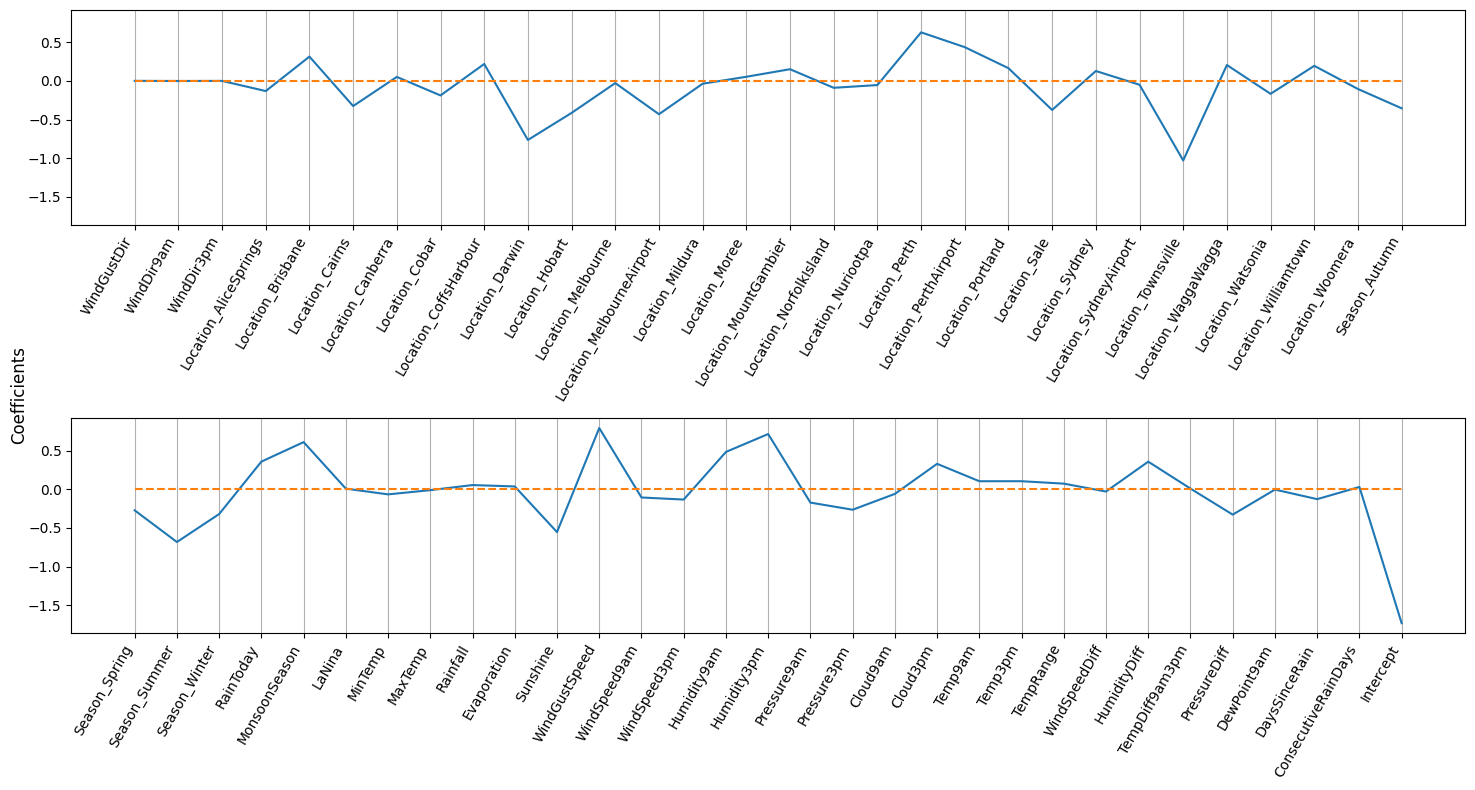

In [ ]:
f, axs = plt.subplots(nrows=2, sharey=True, figsize=(15,8), dpi=dev_dpi if dev_mode else prod_dpi)

n_feat = len(fitted_features)
half = n_feat // 2

feature_coefs(axs[0], lr_coef[:half], fitted_features[:half])
feature_coefs(axs[1], lr_coef[half:], fitted_features[half:])
# TODO: legend
f.supylabel('Coefficients')
f.tight_layout()
plt.show();

##### Optimizing Parameters

In [23]:
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegressionCV

if optimize["Logistic Regression"]:
    cs = np.logspace(-6, 1, 1000)
    lrcv = make_pipeline(clone(preprocessing), LogisticRegressionCV(Cs=cs, max_iter=10000, random_state=rng))
    lrcv.fit(X_train, y_train)

In [44]:
if optimize["Logistic Regression"]:
    lrcv_model = lrcv['logisticregressioncv']
    models['logisticregressioncv'] = {"pipeline": lrcv, "model": lrcv_model, "cv_method": lrcv_model}
    coefs_ = lrcv_model.coefs_paths_[1]

Logistic regression path of C (inverse of regression strength) vs. coefficients

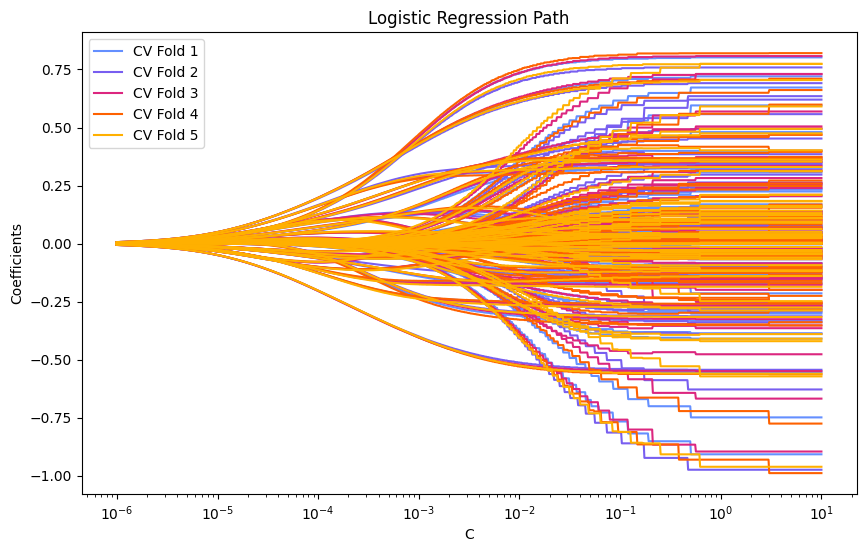

In [25]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

if optimize["Logistic Regression"]:
    # Colorblind-friendly palette (IBM Color Blind Safe palette)
    colors = ["#648FFF", "#785EF0", "#DC267F", "#FE6100", "#FFB000"]

    plt.figure(figsize=(10, 6), dpi=dev_dpi if dev_mode else prod_dpi)
    for j in range(coefs_.shape[0]):
        for i in range(coefs_.shape[2]-1):
            plt.plot(cs, coefs_[j, :, i], color=colors[j])

    ymin, ymax = plt.ylim()
    plt.xscale('log')
    plt.xlabel("C")
    plt.ylabel("Coefficients")
    plt.title("Logistic Regression Path")
    plt.legend(handles=[mlines.Line2D([], [], color=colors[i], label=f'CV Fold {i+1}') for i in range(len(colors))])
    plt.axis("tight")
    plt.show()

That's unintelligible (it's literally $5 \times 60 = 300$ plots). But from the few strands we can pick out, the folds seem to be generally aligned. At least enough so that we can just look at one of them and call it a day

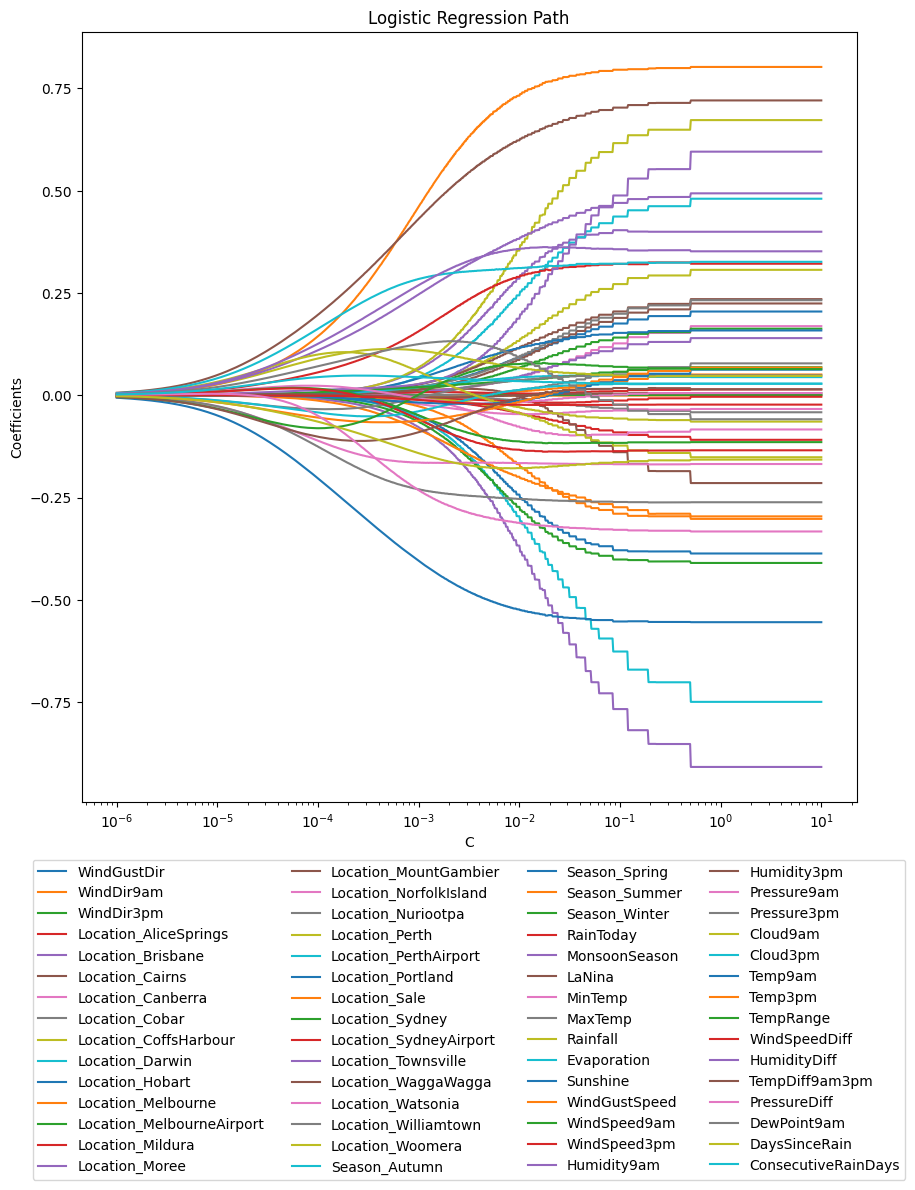

In [26]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

if optimize["Logistic Regression"]:
    # Colorblind-friendly palette (IBM Color Blind Safe palette)
    plt.figure(figsize=(10, 10), dpi=dev_dpi if dev_mode else prod_dpi)
    for i in range(coefs_.shape[2]-1):
        plt.plot(cs, coefs_[0, :, i], label=fitted_features[i])

    ymin, ymax = plt.ylim()
    plt.xscale('log')
    plt.xlabel("C")
    plt.ylabel("Coefficients")
    plt.title("Logistic Regression Path")
    plt.legend(ncol=4, loc='lower center', bbox_to_anchor=(0.5, -0.5))
    plt.axis("tight")
    plt.show()

C (inverse of regularization strength) vs. Accuracy

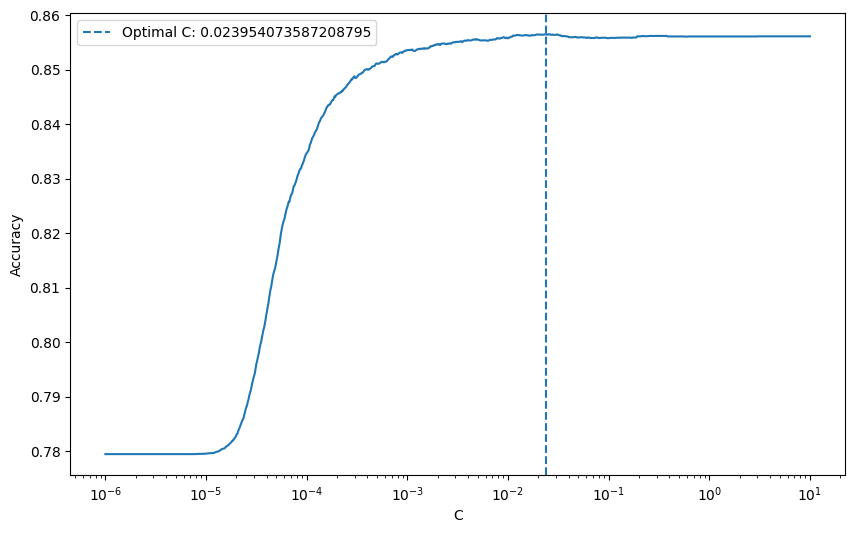

In [27]:
if optimize["Logistic Regression"]:
    f, ax = plt.subplots(figsize=(10, 6), dpi=dev_dpi if dev_mode else prod_dpi)

    mean_scores = lrcv_model.scores_[1].mean(axis=0)
    ax.plot(cs, mean_scores)
    ax.axvline(lrcv_model.C_[0], ls='--', label=f"Optimal C: {lrcv_model.C_[0]}")
    ax.set_xscale('log')
    ax.set_ylabel('Accuracy')
    ax.set_xlabel('C')
    plt.legend()
    plt.plot();

Visualize optimal coefficients

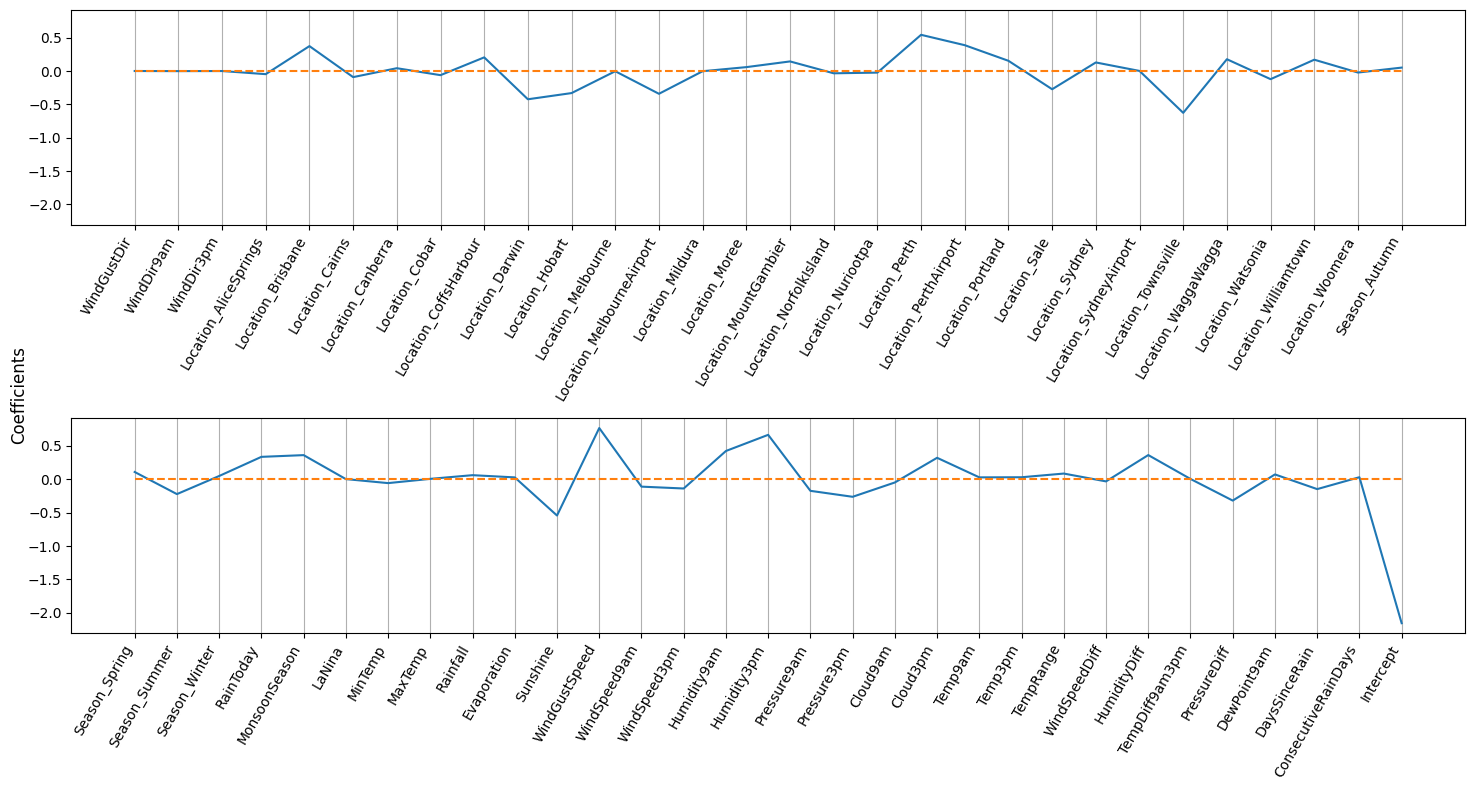

In [ ]:
if optimize["Logistic Regression"]:
    lrcv_coef = lrcv_model.coef_[0]
    fitted_features = lr['columntransformer'].get_feature_names_out()
    fitted_features = list(map(lambda n, s: s[n+2:], np.vectorize(lambda s: s.find('__'))(fitted_features), fitted_features))
    lrcv_coef = np.append(lrcv_coef, lrcv_model.intercept_)
    fitted_features.append('Intercept')

    f, axs = plt.subplots(nrows=2, figsize=(15,8), dpi=dev_dpi if dev_mode else prod_dpi)

    n_feat = len(fitted_features)
    half = n_feat // 2

    feature_coefs(axs[0], lrcv_coef[:half], fitted_features[:half])
    feature_coefs(axs[1], lrcv_coef[half:], fitted_features[half:])
    # TODO: legend
    # TODO: sharey?
    axs[0].sharey(axs[1])
    f.supylabel('Coefficients')
    f.tight_layout()
    plt.show();

Visualize optimal coefficients against default (they're basically the same)

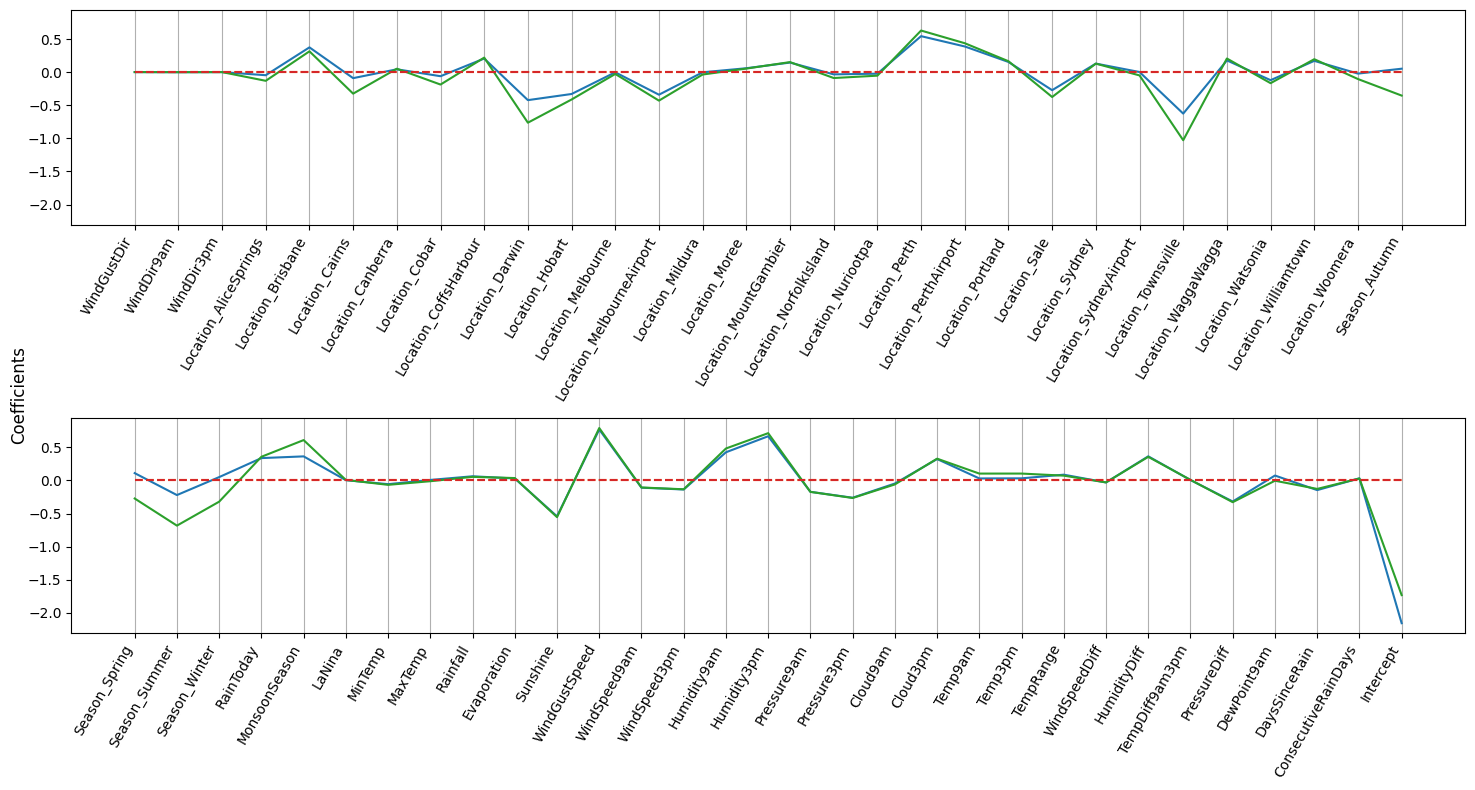

In [ ]:
if optimize["Logistic Regression"]:
    lrcv_coef = lrcv_model.coef_[0]
    fitted_features = lr['columntransformer'].get_feature_names_out()
    fitted_features = list(map(lambda n, s: s[n+2:], np.vectorize(lambda s: s.find('__'))(fitted_features), fitted_features))
    lrcv_coef = np.append(lrcv_coef, lrcv_model.intercept_)
    fitted_features.append('Intercept')

    f, axs = plt.subplots(nrows=2, figsize=(15,8), dpi=dev_dpi if dev_mode else prod_dpi)

    n_feat = len(fitted_features)
    half = n_feat // 2

    feature_coefs(axs[0], lrcv_coef[:half], fitted_features[:half])
    feature_coefs(axs[1], lrcv_coef[half:], fitted_features[half:])
    feature_coefs(axs[0], lr_coef[:half], fitted_features[:half])
    feature_coefs(axs[1], lr_coef[half:], fitted_features[half:])
    # TODO: legend
    # TODO: sharey?
    axs[0].sharey(axs[1])
    axs[0].xaxis.grid()
    axs[1].xaxis.grid()
    f.supylabel('Coefficients')
    f.tight_layout()
    plt.show();

#### Decision Tree Classifier

In [30]:
from sklearn.tree import DecisionTreeClassifier

tree = make_pipeline(clone(preprocessing), DecisionTreeClassifier(max_depth=3, random_state=rng))
tree.fit(X_train, y_train)

,steps,"[('columntransformer', ...), ('decisiontreeclassifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('functiontransformer-1', ...), ('onehotencoder', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [45]:
models["decisiontreeclassifier"] = {"pipeline": tree, "model": tree['decisiontreeclassifier']}

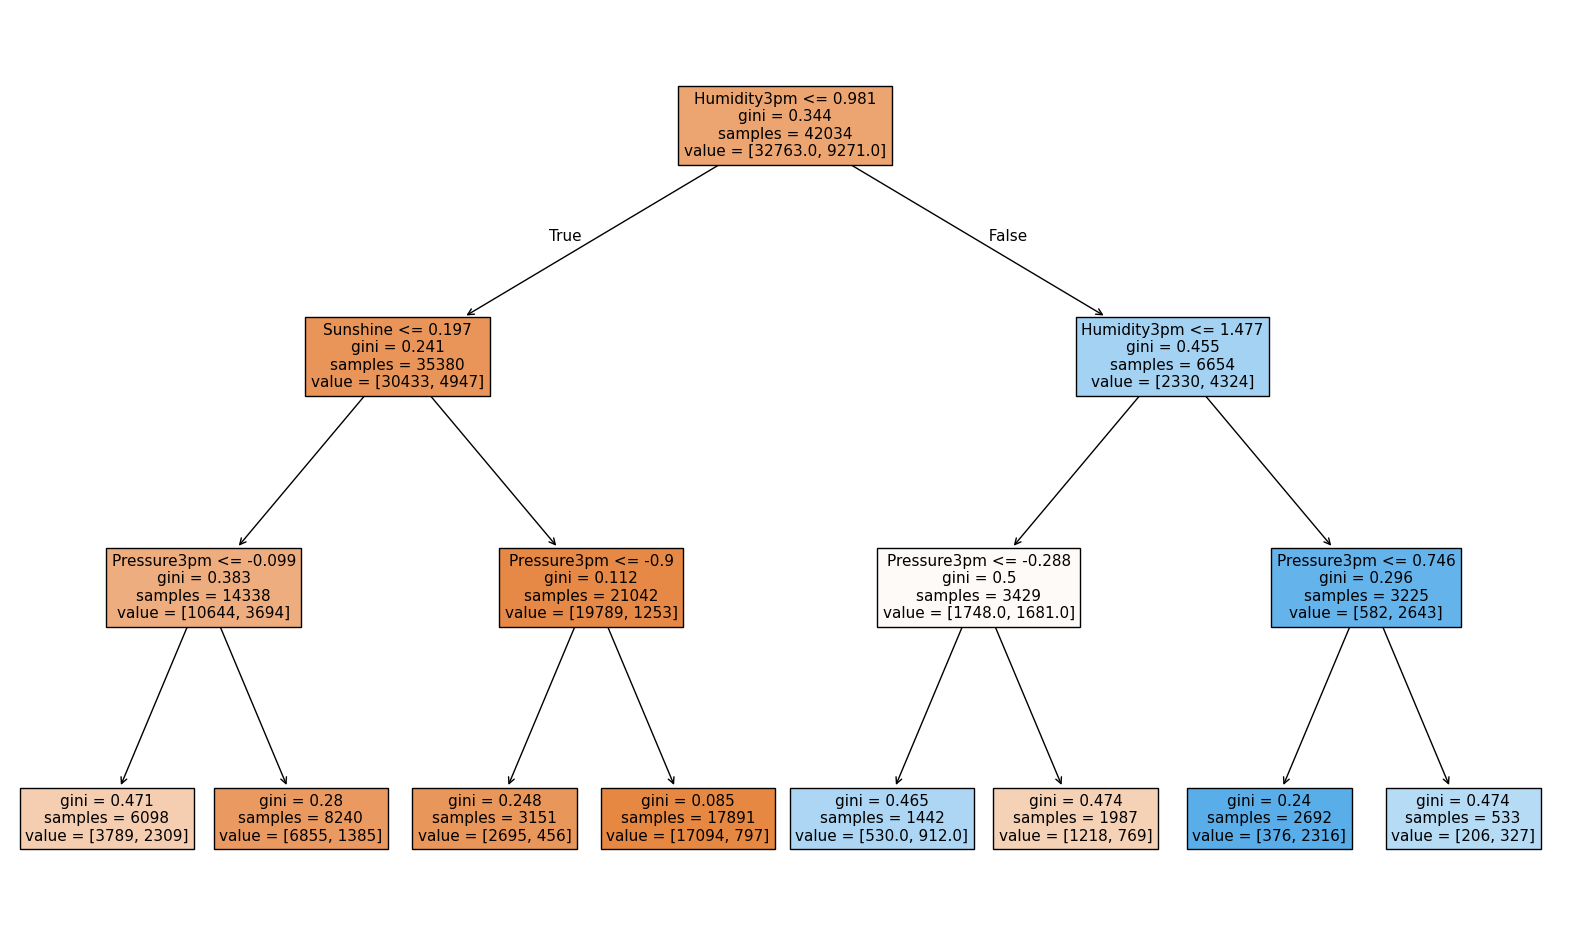

In [31]:
from sklearn.tree import plot_tree as sklearn_plot_tree

def plot_tree(tree):
    f, ax = plt.subplots(figsize=(20, 12), dpi=dev_dpi if dev_mode else prod_dpi)
    sklearn_plot_tree(tree, feature_names=fitted_features, fontsize=11, filled=True, ax=ax);

plot_tree(tree['decisiontreeclassifier'])

##### Optimized Parameters
* `max_depth`
* `min_samples_split`
* `min_samples_leaf`

In [32]:
from sklearn.model_selection import GridSearchCV
if optimize["Decision Tree"]:
    param_grid = {
        'max_depth': range(1, 11),
        'min_samples_split': range(2, 21),
        'min_samples_leaf': range(1, 21),
    }
    treecv = make_pipeline(clone(preprocessing), GridSearchCV(DecisionTreeClassifier(random_state=rng), param_grid, verbose=0))
    treecv.fit(X_train, y_train)

In [46]:
if optimize["Decision Tree"]:
    treecv_model = treecv['gridsearchcv']
    models['decisiontreecv'] = {"pipeline": treecv, "model": treecv_model.best_estimator_, "cv_method": treecv_model}
    best_tree = treecv_model.best_estimator_
    score_columns = ['split0_test_score', 'split1_test_score', 'split2_test_score', 'split3_test_score', 'split4_test_score', 'mean_test_score']
    columns = ['param_max_depth', 'param_min_samples_split', 'param_min_samples_leaf']
    columns.extend(score_columns)

    scores = pd.DataFrame(treecv_model.cv_results_)[columns]

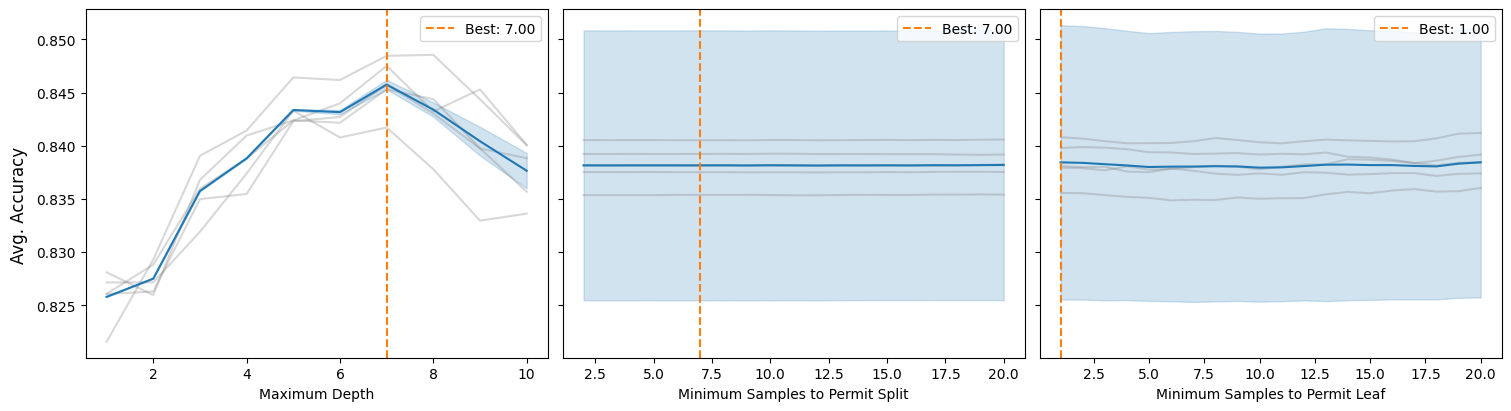

In [34]:
if optimize["Decision Tree"]:
    f, axs = plt.subplots(ncols=3, layout='constrained', sharey=True, figsize=(15, 4), dpi=dev_dpi if dev_mode else prod_dpi)

    mean_col = 'mean_test_score'

    # max_depth
    depth_ax = axs[0]
    by_depth_mean = scores.groupby('param_max_depth')[score_columns].mean()
    by_depth_95ci = scores.groupby('param_max_depth')[mean_col].std() * 1.96
    for i in by_depth_mean.columns[:-1]:
        depth_ax.plot(param_grid['max_depth'], by_depth_mean[i], color="tab:grey", alpha=0.3)
    depth_ax.plot(param_grid['max_depth'], by_depth_mean[mean_col], color="tab:blue", alpha=1)
    depth_ax.fill_between(param_grid['max_depth'], by_depth_mean[mean_col]-by_depth_95ci, by_depth_mean[mean_col]+by_depth_95ci,
                        color="tab:blue", alpha=0.2)
    best_depth = best_tree.get_params()['max_depth']
    depth_ax.axvline(best_depth, ls='--', color='tab:orange', label=f"Best: {best_depth:.2f}")
    depth_ax.set_xlabel("Maximum Depth")

    # min_samples_split
    split_ax = axs[1]
    by_split_mean = scores.groupby('param_min_samples_split')[score_columns].mean()
    by_split_95ci = scores.groupby('param_min_samples_split')[mean_col].std() * 1.96
    for i in by_split_mean.columns[:-1]:
        split_ax.plot(param_grid['min_samples_split'], by_split_mean[i], color="tab:gray", alpha=0.3)
    split_ax.plot(param_grid['min_samples_split'], by_split_mean[mean_col], color="tab:blue", alpha=1)
    split_ax.fill_between(param_grid['min_samples_split'], by_split_mean[mean_col]-by_split_95ci, by_split_mean[mean_col]+by_split_95ci,
                        color="tab:blue", alpha=0.2)
    best_split = best_tree.get_params()['min_samples_split']
    split_ax.axvline(best_split, ls='--', color='tab:orange', label=f"Best: {best_split:.2f}")
    split_ax.set_xlabel("Minimum Samples to Permit Split")

    # min_samples_leaf
    leaf_ax = axs[2]
    by_leaf_mean = scores.groupby('param_min_samples_leaf')[score_columns].mean()
    by_leaf_95ci = scores.groupby('param_min_samples_leaf')[mean_col].std() * 1.96
    for i in by_leaf_mean.columns[:-1]:
        leaf_ax.plot(param_grid['min_samples_leaf'], by_leaf_mean[i], color="tab:gray", alpha=0.3)
    leaf_ax.plot(param_grid['min_samples_leaf'], by_leaf_mean[mean_col], color="tab:blue", alpha=1)
    leaf_ax.fill_between(param_grid['min_samples_leaf'], by_leaf_mean[mean_col]-by_leaf_95ci, by_leaf_mean[mean_col]+by_leaf_95ci,
                        color="tab:blue", alpha=0.2)
    best_leaf = best_tree.get_params()['min_samples_leaf']
    leaf_ax.axvline(best_leaf, ls='--', color='tab:orange', label=f"Best: {best_leaf:.2f}")
    leaf_ax.set_xlabel("Minimum Samples to Permit Leaf")

    f.supylabel("Avg. Accuracy")
    for ax in axs:
        ax.legend(loc="upper right")
    plt.show();

Best max_depth: 7
Best min_samples_split: 7
Best min_samples_leaf: 1


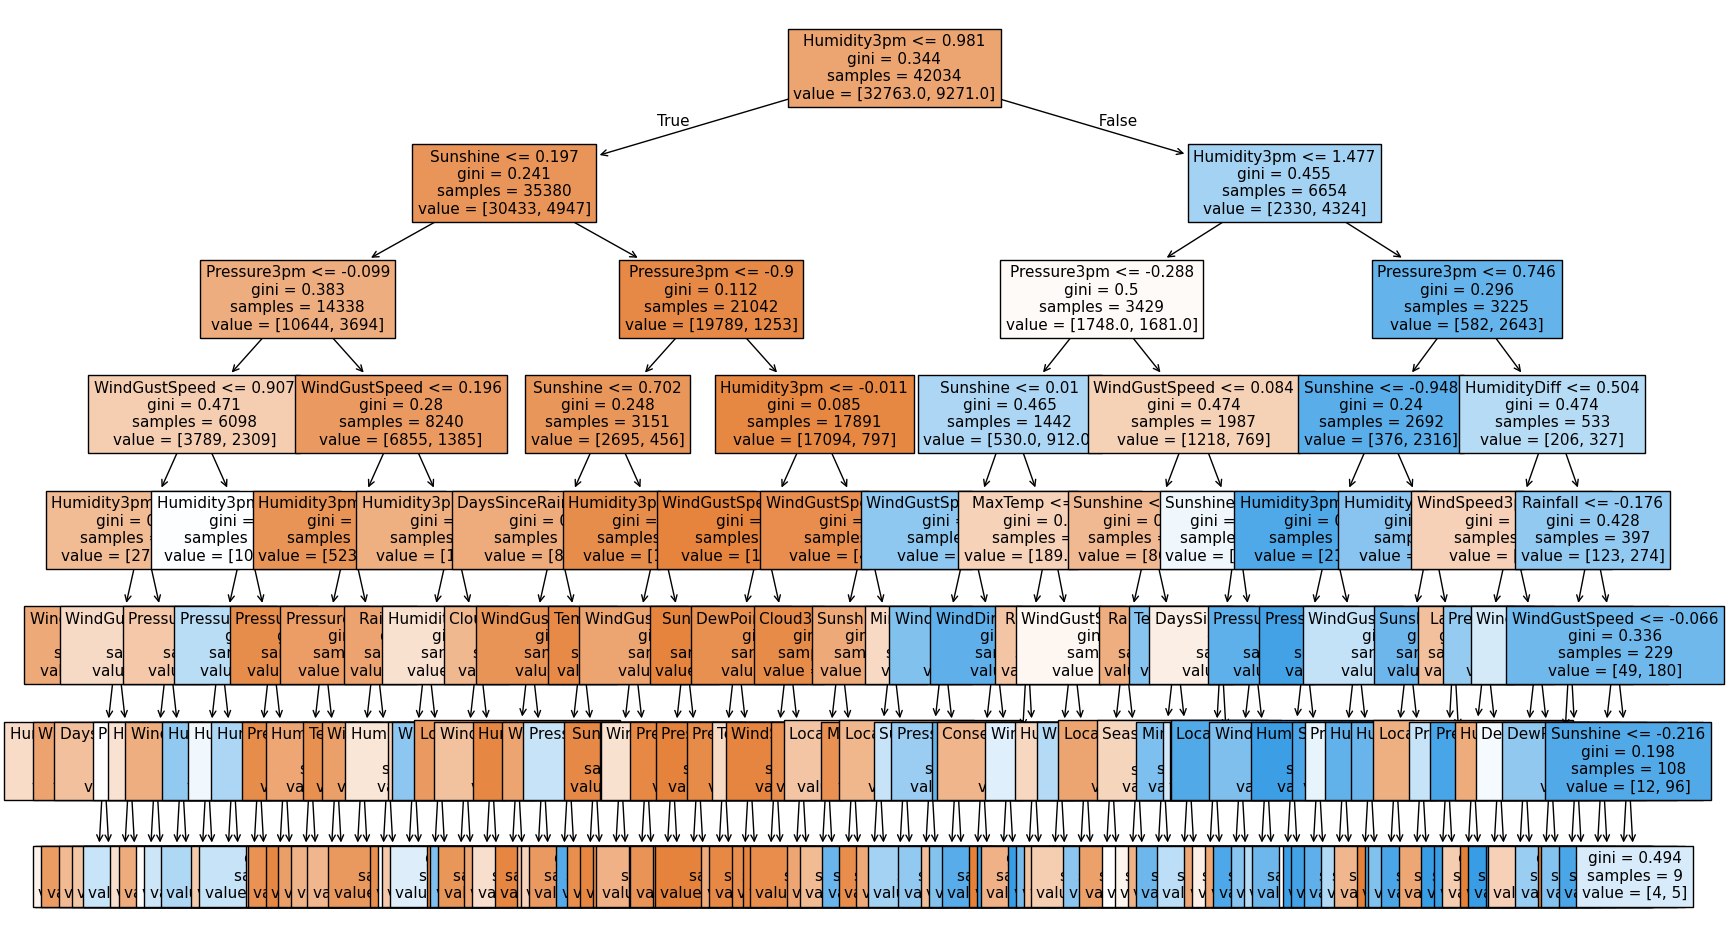

In [35]:
if optimize["Decision Tree"]:
    print("Best max_depth:", best_tree.get_params()['max_depth'])
    print("Best min_samples_split:", best_tree.get_params()['min_samples_split'])
    print("Best min_samples_leaf:", best_tree.get_params()['min_samples_leaf'])
    plot_tree(best_tree)

#### Post-Pruning
with ccp_alpha on optimal tree

In [36]:
if optimize["Decision Tree"]:
    X_ = clone(preprocessing).fit_transform(X)
    y_ = y
    X_train_, X_test_, y_train_, y_test_ = train_test_split(X_, y_, test_size=test_size, random_state=rng)

    clf = clone(best_tree)
    path = clf.cost_complexity_pruning_path(X_train_, y_train_)
    ccp_alphas, impurities = path.ccp_alphas, path.impurities

    clfs = []
    print(f"Running {len(ccp_alphas)} alphas...")
    for ccp_alpha in ccp_alphas:
        clf = DecisionTreeClassifier(random_state=0, ccp_alpha=ccp_alpha)
        clf.fit(X_train_, y_train_)
        clfs.append(clf)
    print(
        "Number of nodes in the last tree is: {} with ccp_alpha: {}".format(
            clfs[-1].tree_.node_count, ccp_alphas[-1]
        )
    )

Running 111 alphas...
Number of nodes in the last tree is: 1 with ccp_alpha: 0.06931487404428904


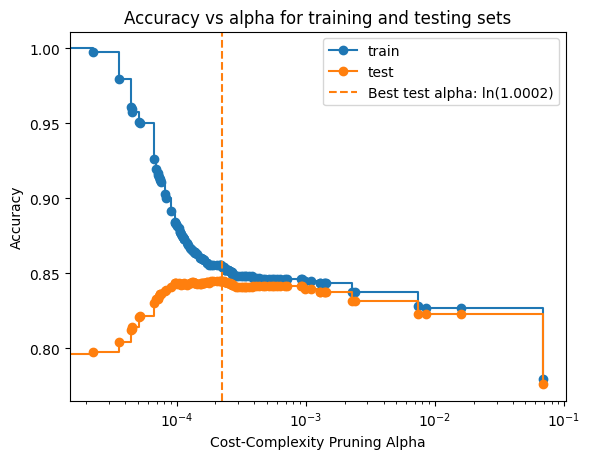

In [37]:
if optimize["Decision Tree"]:
    train_scores = np.array([clf.score(X_train_, y_train_) for clf in clfs])
    test_scores = np.array([clf.score(X_test_, y_test_) for clf in clfs])

    fig, ax = plt.subplots(dpi=dev_dpi if dev_mode else prod_dpi)

    ax.plot(ccp_alphas, train_scores, marker="o", label="train", drawstyle="steps-post")
    ax.plot(ccp_alphas, test_scores, marker="o", label="test", drawstyle="steps-post")

    best_alpha = ccp_alphas[test_scores.argmax()]
    ax.axvline(best_alpha, ls='--', color="tab:orange", label=f"Best test alpha: ln({np.exp(best_alpha):.5g})")

    ax.set_xscale('log')
    ax.set_xlabel("Cost-Complexity Pruning Alpha")
    ax.set_ylabel("Accuracy")
    ax.set_title("Accuracy vs alpha for training and testing sets")
    ax.legend()
    plt.show()

Best max_depth: 7
Best min_samples_split: 7
Best min_samples_leaf: 1


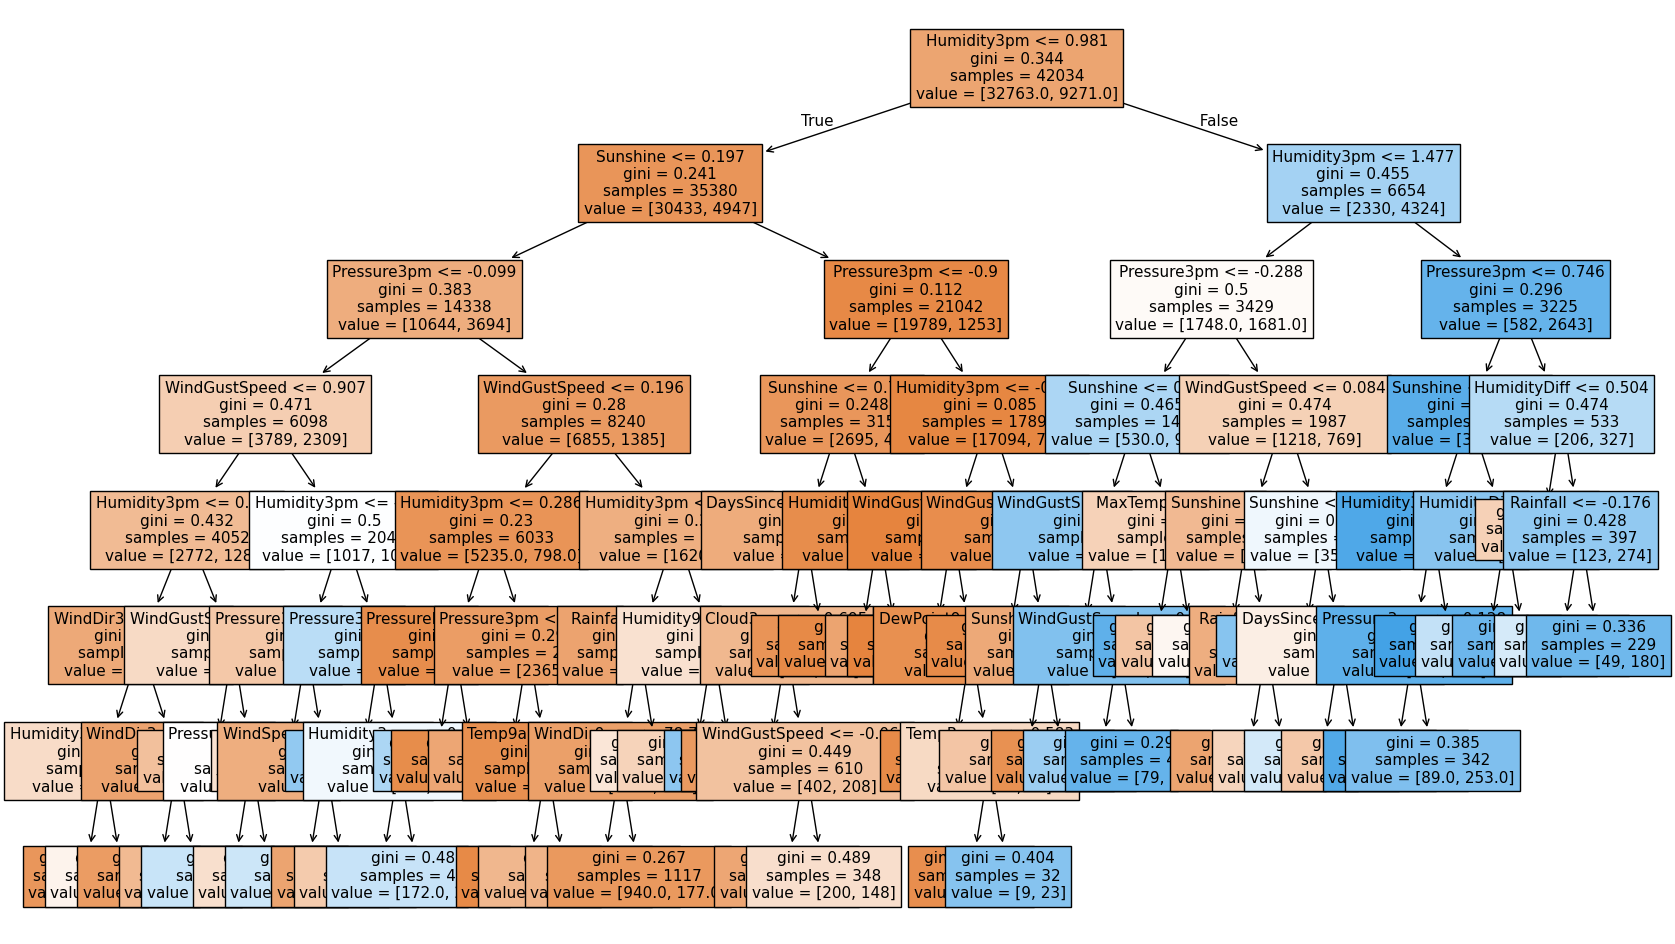

In [47]:
if optimize["Decision Tree"]:
    pruned_tree = make_pipeline(clone(preprocessing), clone(best_tree).set_params(ccp_alpha=best_alpha))
    pruned_tree.fit(X_train, y_train)
    pruned_tree_model = pruned_tree['decisiontreeclassifier']
    models["best_prunedtree"] = {"pipeline": pruned_tree, "model": pruned_tree_model, 
                                 "cost_complexity_pruning": {"model": clf, "cost_complexity_pruning_path": path}}
    print("Best max_depth:", pruned_tree_model.get_params()['max_depth'])
    print("Best min_samples_split:", pruned_tree_model.get_params()['min_samples_split'])
    print("Best min_samples_leaf:", pruned_tree_model.get_params()['min_samples_leaf'])
    plot_tree(pruned_tree_model)

### Improved Model
Random forest, boosting, other ensemble

#### Bagging

In [39]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bags = ensemble.BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=4, random_state=rng),
    n_estimators=100,
    random_state=rng
)

NameError: name 'ensemble' is not defined

#### Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

forest = ensemble.RandomForestClassifier(
    n_estimators=300,
    max_depth=4,
    max_features='sqrt',
    random_state=rng
)

#### Boosting

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

boost = ensemble.GradientBoostingClassifier(
    n_estimators=120,
    max_depth=4,
    random_state=rng
)

## Evaluation
With confucion matrix and suitable classification matrix

## Limitations

### False Positives and Negatives

## References